In [2]:
import pandas as pd

In [3]:
orders = pd.read_csv('/Users/nasreenkhalid/Downloads/orders.csv')

In [4]:
products = pd.read_csv('/Users/nasreenkhalid/Downloads/products.csv')

In [5]:
customers = pd.read_csv('/Users/nasreenkhalid/Downloads/customers.csv')

In [6]:
targets = pd.read_csv('/Users/nasreenkhalid/Downloads/targets.csv')

In [7]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status
0,1001,2024-01-05,C001,P01,2,"$1,200",North,Ali,Completed
1,1002,01/06/2024,C002,P02,3,500,south,Sara,Completed
2,1003,2024-01-08,C003,P03,1,$800,NORTH,Omar,Completed
3,1004,2024/01/12,C004,P04,5,250,East,Lina,Completed
4,1005,"Jan 15, 2024",C005,P02,2,500,West,Ali,Completed


In [8]:
products.head()

,Product_ID,Product_Name,Category,Subcategory
0,P01,Laptop,Electronics,Computing
1,P02,Phone,Electronics,Mobile
2,P03,Tablet,Electronics,Mobile
3,P04,Office Chair,Furniture,Office
4,P05,Mouse,Accessories,Computer Accessories


In [9]:
orders.shape

(61, 9)

In [10]:
products.shape , customers.shape, targets.shape

((10, 4), (57, 5), (48, 3))

In [11]:
orders.columns, products.columns , customers.columns, targets.columns

(Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Quantity',
        'Unit_Price', 'Region', 'Sales_Rep', 'Status'],
       dtype='str'),
 Index(['Product_ID', 'Product_Name', 'Category', 'Subcategory'], dtype='str'),
 Index(['Customer_ID', 'Customer_Name', 'Customer_Segment', 'City', 'Region'], dtype='str'),
 Index(['Month', 'Region', 'Sales_Target'], dtype='str'))

In [12]:
orders.count(), products.count() , customers.count(), targets.count()

(Order_ID       61
 Order_Date     61
 Customer_ID    61
 Product_ID     61
 Quantity       61
 Unit_Price     61
 Region         61
 Sales_Rep      61
 Status         61
 dtype: int64,
 Product_ID      10
 Product_Name    10
 Category        10
 Subcategory     10
 dtype: int64,
 Customer_ID         57
 Customer_Name       57
 Customer_Segment    57
 City                57
 Region              57
 dtype: int64,
 Month           48
 Region          48
 Sales_Target    48
 dtype: int64)

In [13]:
orders.info(), products.info() , customers.info(), targets.info()

<class 'pandas.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Order_ID     61 non-null     int64
 1   Order_Date   61 non-null     str  
 2   Customer_ID  61 non-null     str  
 3   Product_ID   61 non-null     str  
 4   Quantity     61 non-null     int64
 5   Unit_Price   61 non-null     str  
 6   Region       61 non-null     str  
 7   Sales_Rep    61 non-null     str  
 8   Status       61 non-null     str  
dtypes: int64(2), str(7)
memory usage: 6.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Product_ID    10 non-null     str  
 1   Product_Name  10 non-null     str  
 2   Category      10 non-null     str  
 3   Subcategory   10 non-null     str  
dtypes: str(4)
memory usage: 765.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 57 entr

(None, None, None, None)

In [16]:
customers[customers.duplicated(keep=False)]

,Customer_ID,Customer_Name,Customer_Segment,City,Region


In [17]:
orders.isnull().any().any()

np.False_

In [18]:
products.isnull().any().any()

np.False_

In [19]:
customers.isnull().any().any()

np.False_

In [20]:
targets.isnull().any().any()

np.False_

In [21]:
orders.duplicated().sum()

np.int64(1)

In [22]:
products.duplicated().sum()

np.int64(0)

In [23]:
customers.duplicated().sum()

np.int64(0)

In [24]:
targets.duplicated().sum()

np.int64(0)

In [25]:
orders[orders.duplicated()]

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status
20,1020,2024-03-30,C015,P09,2,400,West,Lina,Completed


In [29]:
(orders['Quantity'] < 0).any()

np.True_

In [30]:
negative_orders = (orders['Quantity']<0).any()

In [31]:
print(negative_orders)

True


In [33]:
negative_orders

np.True_

In [36]:
negative_orders = (orders['Quantity']<0)

In [37]:
print(negative_orders)

0     False
1     False
2     False
3     False
4     False
      ...  
56    False
57    False
58    False
59    False
60    False
Name: Quantity, Length: 61, dtype: bool


In [45]:
negative_orders = orders[orders['Quantity'] < 0][['Quantity','Order_ID','Unit_Price','Status']]

In [42]:
negative_orders

,Quantity,Order_ID,Unit_Price
25,-1,1025,1200


In [50]:
returns = orders[orders['Status'] == 'Returned']

In [51]:
print(returns)

    Order_ID  Order_Date Customer_ID Product_ID  Quantity Unit_Price Region  \
25      1025  2024-04-25        C020        P01        -1       1200  North   

   Sales_Rep    Status  
25       Ali  Returned  


In [54]:
print(orders[orders.duplicated()])

Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_ID, Product_ID, Quantity, Unit_Price, Region, Sales_Rep, Status]
Index: []


In [53]:
orders.drop_duplicates(inplace=True)

In [57]:
print(orders['Order_Date'].dtype)

str


In [58]:
print(orders['Order_Date'].head(20))

0       2024-01-05
1       01/06/2024
2       2024-01-08
3       2024/01/12
4     Jan 15, 2024
5       2024-01-18
6       2024-01-20
7       2024-01-25
8       2024-02-02
9       02/05/2024
10      2024-02-10
11      2024-02-14
12      2024-02-20
13      2024-02-28
14      2024-03-03
15      2024-03-07
16      2024-03-12
17      2024-03-15
18      2024-03-22
19      2024-03-30
Name: Order_Date, dtype: str


In [59]:
orders['Order_Date'] = pd.to_datetime(orders['Order_Date'], format='%Y-%m-%d', errors='coerce')

In [60]:
print(orders['Order_Date'].head(20))

0    2024-01-05
1           NaT
2    2024-01-08
3           NaT
4           NaT
5    2024-01-18
6    2024-01-20
7    2024-01-25
8    2024-02-02
9           NaT
10   2024-02-10
11   2024-02-14
12   2024-02-20
13   2024-02-28
14   2024-03-03
15   2024-03-07
16   2024-03-12
17   2024-03-15
18   2024-03-22
19   2024-03-30
Name: Order_Date, dtype: datetime64[us]


In [62]:
orders['Order_Date'] = orders['Order_Date'].fillna(pd.Timestamp.now())

In [63]:
print(orders['Order_Date'].head(20))

0    2024-01-05 00:00:00.000000
1    2026-09-06 13:01:52.350848
2    2024-01-08 00:00:00.000000
3    2026-09-06 13:01:52.350848
4    2026-09-06 13:01:52.350848
5    2024-01-18 00:00:00.000000
6    2024-01-20 00:00:00.000000
7    2024-01-25 00:00:00.000000
8    2024-02-02 00:00:00.000000
9    2026-09-06 13:01:52.350848
10   2024-02-10 00:00:00.000000
11   2024-02-14 00:00:00.000000
12   2024-02-20 00:00:00.000000
13   2024-02-28 00:00:00.000000
14   2024-03-03 00:00:00.000000
15   2024-03-07 00:00:00.000000
16   2024-03-12 00:00:00.000000
17   2024-03-15 00:00:00.000000
18   2024-03-22 00:00:00.000000
19   2024-03-30 00:00:00.000000
Name: Order_Date, dtype: datetime64[us]


In [65]:
gross_sales = (orders['Quantity']* orders['Unit_Price']).sum()

In [70]:
orders.dtypes

Order_ID                int64
Order_Date     datetime64[us]
Customer_ID               str
Product_ID                str
Quantity                int64
Unit_Price                str
Region                    str
Sales_Rep                 str
Status                    str
dtype: object

In [72]:
orders["Unit_Price"] = (
    orders["Unit_Price"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
)

print(orders)

    Order_ID                 Order_Date Customer_ID Product_ID  Quantity  \
0       1001 2024-01-05 00:00:00.000000        C001        P01         2   
1       1002 2026-09-06 13:01:52.350848        C002        P02         3   
2       1003 2024-01-08 00:00:00.000000        C003        P03         1   
3       1004 2026-09-06 13:01:52.350848        C004        P04         5   
4       1005 2026-09-06 13:01:52.350848        C005        P02         2   
5       1006 2024-01-18 00:00:00.000000        C001        P01         1   
6       1007 2024-01-20 00:00:00.000000        C006        P05         4   
7       1008 2024-01-25 00:00:00.000000        C007        P03         2   
8       1009 2024-02-02 00:00:00.000000        C008        P06         3   
9       1010 2026-09-06 13:01:52.350848        C002        P02         1   
10      1011 2024-02-10 00:00:00.000000        C009        P07         2   
11      1012 2024-02-14 00:00:00.000000        C010        P01         1   
12      1013

In [73]:
gross_sales = (orders['Quantity']* orders['Unit_Price']).sum()
print(gross_sales)

65475.0


In [74]:
print(f"\nGross Sales: ${gross_sales:,.2f}")


Gross Sales: $65,475.00


In [76]:
returns = abs((orders[orders['Status'] == 'Returned']['Quantity'] * 
               orders[orders['Status'] == 'Returned']['Unit_Price']).sum())
print(f"Total Returns: ${returns:,.2f}")

Total Returns: $1,200.00


In [77]:
net_sales = gross_sales - returns

In [78]:
print(net_sales)

64275.0


In [79]:
print(f"Net Sales: ${net_sales:,.2f}")

Net Sales: $64,275.00


In [81]:
sales = orders['Quantity'] * orders ['Unit_Price']


In [83]:
orders.head(4)

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status
0,1001,2024-01-05 00:00:00.000000,C001,P01,2,1200.0,North,Ali,Completed
1,1002,2026-09-06 13:01:52.350848,C002,P02,3,500.0,south,Sara,Completed
2,1003,2024-01-08 00:00:00.000000,C003,P03,1,800.0,NORTH,Omar,Completed
3,1004,2026-09-06 13:01:52.350848,C004,P04,5,250.0,East,Lina,Completed


In [84]:
orders['Sales'] = sales

In [85]:
orders.head(4)

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status,Sales
0,1001,2024-01-05 00:00:00.000000,C001,P01,2,1200.0,North,Ali,Completed,2400.0
1,1002,2026-09-06 13:01:52.350848,C002,P02,3,500.0,south,Sara,Completed,1500.0
2,1003,2024-01-08 00:00:00.000000,C003,P03,1,800.0,NORTH,Omar,Completed,800.0
3,1004,2026-09-06 13:01:52.350848,C004,P04,5,250.0,East,Lina,Completed,1250.0


In [86]:
monthly_sales = (orders.groupby(orders['Order_Date'].dt.to_period("M"))['Sales'].sum().reset_index(name="total_sales"))


In [87]:
print(monthly_sales)

   Order_Date  total_sales
0     2024-01       6600.0
1     2024-02       6900.0
2     2024-03       6450.0
3     2024-04       2150.0
4     2024-05       7700.0
5     2024-06       4325.0
6     2024-07       7250.0
7     2024-08       4350.0
8     2024-09       4750.0
9     2024-10       2650.0
10    2024-11       4375.0
11    2024-12       3650.0
12    2026-09       4325.0


In [88]:
import matplotlib.pyplot as plt

<Axes: xlabel='Order_Date'>

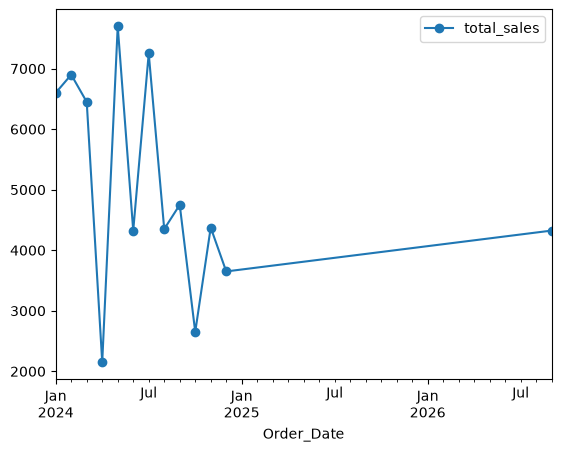

In [89]:
monthly_sales.plot(x='Order_Date', y='total_sales', kind='line', marker='o')

In [93]:
max_sales_idx = monthly_sales['total_sales'].idxmax()

In [94]:
print(max_sales_idx)

4


In [95]:
top_month = monthly_sales.loc[max_sales_idx]
print(f"Month with most sales: {top_month['Order_Date']}")
print(f"Sales: ${top_month['total_sales']:,.2f}")

Month with most sales: 2024-05
Sales: $7,700.00


In [96]:
min_sales_idx = monthly_sales['total_sales'].idxmin()

# Get that row
worst_month = monthly_sales.loc[min_sales_idx]
print(f"Month with least sales: {worst_month['Order_Date']}")
print(f"Sales: ${worst_month['total_sales']:,.2f}")

Month with least sales: 2024-04
Sales: $2,150.00


In [97]:
targets.head()

,Month,Region,Sales_Target
0,2024-01-01,North,4500
1,2024-01-01,South,4000
2,2024-01-01,East,3500
3,2024-01-01,West,3000
4,2024-02-01,North,4700


In [100]:
targets['Month'] = pd.to_datetime(targets['Month'])

In [104]:
targets.dtypes

Month           datetime64[us]
Region                     str
Sales_Target             int64
dtype: object

In [105]:
monthly_targets = (targets.groupby(targets['Month'].dt.to_period("M"))['Sales_Target'].sum().reset_index(name="total_target"))

In [106]:
print(monthly_targets)

      Month  total_target
0   2024-01         15000
1   2024-02         15500
2   2024-03         15900
3   2024-04         16400
4   2024-05         16800
5   2024-06         17200
6   2024-07         17600
7   2024-08         18000
8   2024-09         18400
9   2024-10         18800
10  2024-11         19200
11  2024-12         19600


In [108]:
monthly_sales.rename({"Order_Date":"Month"})

,Order_Date,total_sales
0,2024-01,6600.0
1,2024-02,6900.0
2,2024-03,6450.0
3,2024-04,2150.0
4,2024-05,7700.0
5,2024-06,4325.0
6,2024-07,7250.0
7,2024-08,4350.0
8,2024-09,4750.0
9,2024-10,2650.0


In [109]:
monthly_sales = monthly_sales.rename(columns={"Order_Date": "Month"})

In [110]:
monthly_sales.head()

,Month,total_sales
0,2024-01,6600.0
1,2024-02,6900.0
2,2024-03,6450.0
3,2024-04,2150.0
4,2024-05,7700.0


In [111]:
df_combined = pd.merge(monthly_sales, monthly_targets, on='Month', how='inner')

In [112]:
print(df_combined)

      Month  total_sales  total_target
0   2024-01       6600.0         15000
1   2024-02       6900.0         15500
2   2024-03       6450.0         15900
3   2024-04       2150.0         16400
4   2024-05       7700.0         16800
5   2024-06       4325.0         17200
6   2024-07       7250.0         17600
7   2024-08       4350.0         18000
8   2024-09       4750.0         18400
9   2024-10       2650.0         18800
10  2024-11       4375.0         19200
11  2024-12       3650.0         19600


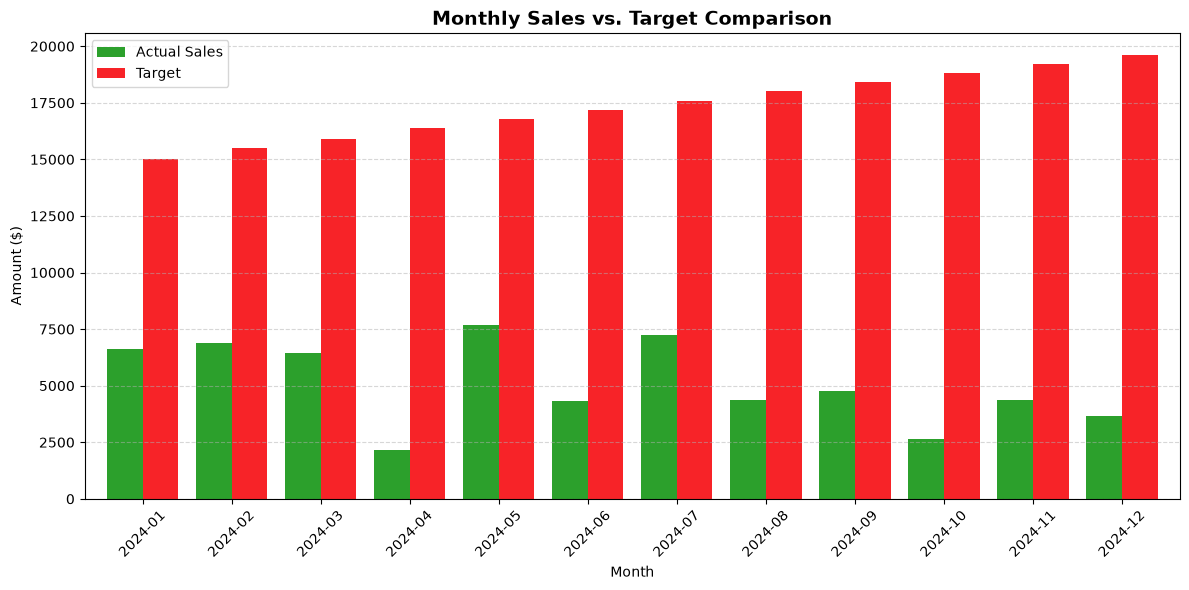

In [116]:
df_combined.plot(
    x='Month', 
    y=['total_sales', 'total_target'],  
    kind='bar',                           
    color=['#2ca02c', '#f72328'],         # Green for sales, red for target
    figsize=(12, 6),
    width=0.8                             
)

plt.title('Monthly Sales vs. Target Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Amount ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)                   
plt.legend(['Actual Sales', 'Target'])
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()                        # Prevents labels from getting cut off
plt.show()

In [117]:
print(df_combined)

      Month  total_sales  total_target
0   2024-01       6600.0         15000
1   2024-02       6900.0         15500
2   2024-03       6450.0         15900
3   2024-04       2150.0         16400
4   2024-05       7700.0         16800
5   2024-06       4325.0         17200
6   2024-07       7250.0         17600
7   2024-08       4350.0         18000
8   2024-09       4750.0         18400
9   2024-10       2650.0         18800
10  2024-11       4375.0         19200
11  2024-12       3650.0         19600


In [118]:
df_combined['Target_Variance'] = df_combined['total_sales'] - df_combined['total_target']

In [119]:
print(df_combined)

      Month  total_sales  total_target  Target_Variance
0   2024-01       6600.0         15000          -8400.0
1   2024-02       6900.0         15500          -8600.0
2   2024-03       6450.0         15900          -9450.0
3   2024-04       2150.0         16400         -14250.0
4   2024-05       7700.0         16800          -9100.0
5   2024-06       4325.0         17200         -12875.0
6   2024-07       7250.0         17600         -10350.0
7   2024-08       4350.0         18000         -13650.0
8   2024-09       4750.0         18400         -13650.0
9   2024-10       2650.0         18800         -16150.0
10  2024-11       4375.0         19200         -14825.0
11  2024-12       3650.0         19600         -15950.0


In [120]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status,Sales
0,1001,2024-01-05 00:00:00.000000,C001,P01,2,1200.0,North,Ali,Completed,2400.0
1,1002,2026-09-06 13:01:52.350848,C002,P02,3,500.0,south,Sara,Completed,1500.0
2,1003,2024-01-08 00:00:00.000000,C003,P03,1,800.0,NORTH,Omar,Completed,800.0
3,1004,2026-09-06 13:01:52.350848,C004,P04,5,250.0,East,Lina,Completed,1250.0
4,1005,2026-09-06 13:01:52.350848,C005,P02,2,500.0,West,Ali,Completed,1000.0


In [121]:
orders.info

<bound method DataFrame.info of     Order_ID                 Order_Date Customer_ID Product_ID  Quantity  \
0       1001 2024-01-05 00:00:00.000000        C001        P01         2   
1       1002 2026-09-06 13:01:52.350848        C002        P02         3   
2       1003 2024-01-08 00:00:00.000000        C003        P03         1   
3       1004 2026-09-06 13:01:52.350848        C004        P04         5   
4       1005 2026-09-06 13:01:52.350848        C005        P02         2   
5       1006 2024-01-18 00:00:00.000000        C001        P01         1   
6       1007 2024-01-20 00:00:00.000000        C006        P05         4   
7       1008 2024-01-25 00:00:00.000000        C007        P03         2   
8       1009 2024-02-02 00:00:00.000000        C008        P06         3   
9       1010 2026-09-06 13:01:52.350848        C002        P02         1   
10      1011 2024-02-10 00:00:00.000000        C009        P07         2   
11      1012 2024-02-14 00:00:00.000000        C010     

In [122]:
orders['Region'] = orders['Region'].replace(
    {'NORTH': 'North',
    'north': 'North',
    'North ': 'North',
    'SOUTH': 'South',
    'south': 'South',
    'South ': 'South',}
)

In [123]:
orders.info

<bound method DataFrame.info of     Order_ID                 Order_Date Customer_ID Product_ID  Quantity  \
0       1001 2024-01-05 00:00:00.000000        C001        P01         2   
1       1002 2026-09-06 13:01:52.350848        C002        P02         3   
2       1003 2024-01-08 00:00:00.000000        C003        P03         1   
3       1004 2026-09-06 13:01:52.350848        C004        P04         5   
4       1005 2026-09-06 13:01:52.350848        C005        P02         2   
5       1006 2024-01-18 00:00:00.000000        C001        P01         1   
6       1007 2024-01-20 00:00:00.000000        C006        P05         4   
7       1008 2024-01-25 00:00:00.000000        C007        P03         2   
8       1009 2024-02-02 00:00:00.000000        C008        P06         3   
9       1010 2026-09-06 13:01:52.350848        C002        P02         1   
10      1011 2024-02-10 00:00:00.000000        C009        P07         2   
11      1012 2024-02-14 00:00:00.000000        C010     

In [125]:
sales_by_region = orders.groupby('Region')['Sales'].sum()

In [126]:
print(sales_by_region)

Region
East     17075.0
North    18450.0
South    12325.0
West     17625.0
Name: Sales, dtype: float64


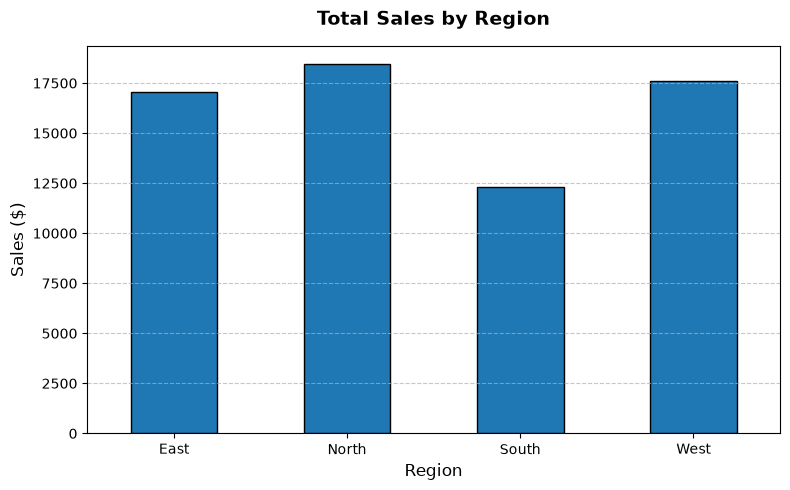

In [128]:
sales_by_region.plot(
    kind='bar', 
    color='#1f77b4',       # Clean professional blue
    edgecolor='black',     # Adds a sharp border to the bars
    figsize=(8, 5)
)

# Customize labels and title
plt.title('Total Sales by Region', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=0)     # Keeps region names horizontal (East, North, etc.) so they are easy to read
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds a light horizontal background grid

# Display the plot
plt.tight_layout()
plt.show()

In [129]:
region_sales = pd.Series({
    'East': 17075.0,
    'North': 18450.0,
    'South': 12325.0,
    'West': 17625.0
})

# Total net sales
net_sales = 64275.00

# Calculate percentage share
region_share = (region_sales / net_sales) * 100
print(region_share.round(2))

East     26.57
North    28.70
South    19.18
West     27.42
dtype: float64


In [130]:
returns_by_region = orders[orders['Status'] == 'Returned'].groupby('Region')['Sales'].sum()
print("Returns Value by Region:")
print(returns_by_region)

Returns Value by Region:
Region
North   -1200.0
Name: Sales, dtype: float64


In [131]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status,Sales
0,1001,2024-01-05 00:00:00.000000,C001,P01,2,1200.0,North,Ali,Completed,2400.0
1,1002,2026-09-06 13:01:52.350848,C002,P02,3,500.0,South,Sara,Completed,1500.0
2,1003,2024-01-08 00:00:00.000000,C003,P03,1,800.0,North,Omar,Completed,800.0
3,1004,2026-09-06 13:01:52.350848,C004,P04,5,250.0,East,Lina,Completed,1250.0
4,1005,2026-09-06 13:01:52.350848,C005,P02,2,500.0,West,Ali,Completed,1000.0


In [132]:
customers_sales = orders.groupby('Customer_ID')['Sales'].sum()

In [137]:
new = orders['Sales'].idxmax()

In [138]:
best_customer = orders.loc[new]

In [139]:
print(best_customer)

Order_ID                      1036
Order_Date     2024-07-03 00:00:00
Customer_ID                   C031
Product_ID                     P08
Quantity                         2
Unit_Price                  2000.0
Region                        West
Sales_Rep                     Lina
Status                   Completed
Sales                       4000.0
Name: 36, dtype: object


In [140]:
# Get the customer with the highest sales
top_customer = customers_sales.idxmax()
top_sales = customers_sales.max()

print(f"Top Customer: {top_customer}")
print(f"Total Sales: ${top_sales:,.2f}")

Top Customer: C001
Total Sales: $4,800.00


In [141]:
# Get top 5 customers
top_5_customers = customers_sales.nlargest(5)
print("Top 5 Customers by Sales:")
print(top_5_customers)

Top 5 Customers by Sales:
Customer_ID
C001    4800.0
C031    4000.0
C003    3200.0
C002    2000.0
C012    2000.0
Name: Sales, dtype: float64


In [142]:
gross_sales = (orders['Quantity'] * orders['Unit_Price']).sum()

# Step 2: Get sales by customer
customer_sales = orders.groupby('Customer_ID')['Sales'].sum()

# Step 3: Get Top 5 customers' total sales
top_5_sales = customer_sales.nlargest(5).sum()

# Step 4: Calculate percentage
top_5_percentage = (top_5_sales / gross_sales) * 100

# Step 5: Display results
print(f"Total Gross Sales: ${gross_sales:,.2f}")
print(f"Top 5 Customers Sales: ${top_5_sales:,.2f}")
print(f"Top 5 Customers Contribution: {top_5_percentage:.2f}%")

Total Gross Sales: $65,475.00
Top 5 Customers Sales: $16,000.00
Top 5 Customers Contribution: 24.44%


In [144]:
returns_by_customers = orders[orders['Status'] == 'Returned'].groupby('Customer_ID')['Sales'].sum()
print("Returns Value by Customers:")
print(returns_by_customers)

Returns Value by Customers:
Customer_ID
C020   -1200.0
Name: Sales, dtype: float64


In [145]:
orders.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Quantity,Unit_Price,Region,Sales_Rep,Status,Sales
0,1001,2024-01-05 00:00:00.000000,C001,P01,2,1200.0,North,Ali,Completed,2400.0
1,1002,2026-09-06 13:01:52.350848,C002,P02,3,500.0,South,Sara,Completed,1500.0
2,1003,2024-01-08 00:00:00.000000,C003,P03,1,800.0,North,Omar,Completed,800.0
3,1004,2026-09-06 13:01:52.350848,C004,P04,5,250.0,East,Lina,Completed,1250.0
4,1005,2026-09-06 13:01:52.350848,C005,P02,2,500.0,West,Ali,Completed,1000.0


In [146]:
sales_by_products = orders.groupby('Product_ID')['Sales'].sum()

In [147]:
print(sales_by_products)

Product_ID
P01     8400.0
P02     8500.0
P03    12000.0
P04     4750.0
P05     2850.0
P06     4500.0
P07     7600.0
P08    12000.0
P09     3600.0
P10     1275.0
Name: Sales, dtype: float64


In [148]:
# Get the product with the highest sales
top_product = sales_by_products.idxmax()
top_product_sale = sales_by_products.max()

print(f"Top Product: {top_product}")
print(f"Total Sales: ${top_product_sale:,.2f}")

Top Product: P03
Total Sales: $12,000.00


In [149]:
product_sales = pd.Series({
    'P01':     8400.0,
'P02':     8500.0,
'P03':  12000.0,
'P04':   4750.0,
'P05':  2850.0,
'P06':     4500.0,
'P07':    7600.0,
'P08':  12000.0,
'P09':  3600.0,
'P10': 1275.0
})

# Total net sales
net_sales = 64275.00

# Calculate percentage share
product_share = (product_sales / net_sales) * 100
print(product_share.round(2))

P01    13.07
P02    13.22
P03    18.67
P04     7.39
P05     4.43
P06     7.00
P07    11.82
P08    18.67
P09     5.60
P10     1.98
dtype: float64
